# ── Change this line to switch players ───────────────────────────────────────
CONFIG_FILE = 'config_sfink37.yaml'
# ─────────────────────────────────────────────────────────────────────────────

In [23]:
# ── Change this line to switch players ───────────────────────────────────────
#CONFIG_FILE = 'config_jf4bes.yaml'
CONFIG_FILE = 'config_sfink37.yaml'
# ─────────────────────────────────────────────────────────────────────────────

In [24]:
import yaml
import chess
import chess.pgn
import json
import glob
import io
import re
import datetime
from collections import Counter, defaultdict
from IPython.display import display, HTML
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

with open(CONFIG_FILE, encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

USERNAME      = cfg['username']
DISPLAY_NAME  = cfg['display_name']
GAMES_DIR     = cfg['games_dir']
TIME_CLASSES  = set(cfg['time_classes'])
EXCLUDE       = set(cfg.get('exclude_months', []))
RATING_FLOOR  = cfg.get('rating_floor', 0)
OPENING_END   = cfg.get('phase_opening_hm', 20)
MG_END        = cfg.get('phase_middlegame_hm', 50)
MIN_OPN_GAMES = cfg.get('min_opening_games', 5)
COL_PRIMARY   = cfg.get('color_primary', '#2980b9')
COL_SECONDARY = cfg.get('color_secondary', '#c0392b')

print(f'Config loaded: {CONFIG_FILE}')
print(f'  Player:       {DISPLAY_NAME} ({USERNAME})')
print(f'  Time classes: {", ".join(sorted(TIME_CLASSES))}')
print(f'  Games dir:    {GAMES_DIR}')
print(f'  Excluding:    {sorted(EXCLUDE) if EXCLUDE else "none"}')

Config loaded: config_sfink37.yaml
  Player:       sfink37 (sfink37)
  Time classes: blitz, bullet
  Games dir:    games_sf
  Excluding:    none


## Step 1 — Load games

In [25]:
def load_games(username, games_dir, time_classes, exclude):
    files = sorted(glob.glob(f'{games_dir}/*.json'))
    files = [f for f in files if not any(ex in f for ex in exclude)]
    games = []
    for f in files:
        with open(f, encoding='utf-8') as fh:
            month = json.load(fh)
        for g in month:
            if g.get('time_class') not in time_classes:
                continue
            white = g.get('white', {})
            black = g.get('black', {})
            if   white.get('username','').lower() == username.lower():
                color, my, opp = 'white', white, black
            elif black.get('username','').lower() == username.lower():
                color, my, opp = 'black', black, white
            else:
                continue
            result = my.get('result', '')
            if   result == 'win': outcome = 'win'
            elif result in ('checkmated','timeout','resigned','lose','abandoned'): outcome = 'loss'
            elif result in ('agreed','stalemate','repetition','insufficient','timevsinsufficient','50move'): outcome = 'draw'
            else: continue
            eco_url = ''
            m = re.search(r'\[ECOUrl "([^"]+)"\]', g.get('pgn', ''))
            if m: eco_url = m.group(1)
            games.append({
                'outcome':    outcome,
                'color':      color,
                'end_reason': result,
                'time_class': g.get('time_class'),
                'pgn':        g.get('pgn', ''),
                'eco_url':    eco_url,
                'my_rating':  my.get('rating', 0),
                'opp_rating': opp.get('rating', 0),
                'end_time':   g.get('end_time', 0),
            })
    return sorted(games, key=lambda x: x['end_time'])

games  = load_games(USERNAME, GAMES_DIR, TIME_CLASSES, EXCLUDE)
losses = [g for g in games if g['outcome'] == 'loss']
wins   = [g for g in games if g['outcome'] == 'win']
draws  = [g for g in games if g['outcome'] == 'draw']
total  = len(games)

print(f'{DISPLAY_NAME}: {total} games loaded')
print(f'  W:{len(wins)}  L:{len(losses)}  D:{len(draws)}')
print(f'  Win rate: {100*len(wins)/total:.1f}%')
tc_counts = Counter(g['time_class'] for g in games)
for tc, n in tc_counts.most_common():
    print(f'  {tc}: {n}')

sfink37: 4412 games loaded
  W:1944  L:2210  D:258
  Win rate: 44.1%
  bullet: 3543
  blitz: 869


## Step 2 — Overall record and color breakdown

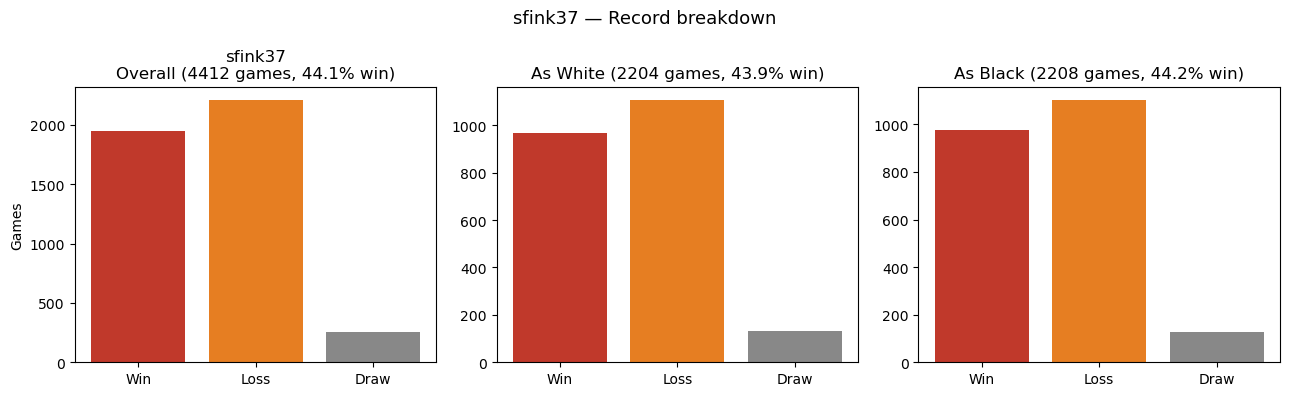

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Overall W/L/D
axes[0].bar(['Win','Loss','Draw'], [len(wins),len(losses),len(draws)],
            color=[COL_PRIMARY, COL_SECONDARY, '#888'], edgecolor='none')
axes[0].set_title(f'{DISPLAY_NAME}\nOverall ({total} games, {100*len(wins)/total:.1f}% win)')
axes[0].set_ylabel('Games')

# As white
w_games = [g for g in games if g['color'] == 'white']
w_wins  = sum(1 for g in w_games if g['outcome'] == 'win')
w_total = len(w_games)
axes[1].bar(['Win','Loss','Draw'],
            [w_wins, sum(1 for g in w_games if g['outcome']=='loss'), sum(1 for g in w_games if g['outcome']=='draw')],
            color=[COL_PRIMARY, COL_SECONDARY, '#888'], edgecolor='none')
axes[1].set_title(f'As White ({w_total} games, {100*w_wins/w_total:.1f}% win)')

# As black
b_games = [g for g in games if g['color'] == 'black']
b_wins  = sum(1 for g in b_games if g['outcome'] == 'win')
b_total = len(b_games)
axes[2].bar(['Win','Loss','Draw'],
            [b_wins, sum(1 for g in b_games if g['outcome']=='loss'), sum(1 for g in b_games if g['outcome']=='draw')],
            color=[COL_PRIMARY, COL_SECONDARY, '#888'], edgecolor='none')
axes[2].set_title(f'As Black ({b_total} games, {100*b_wins/b_total:.1f}% win)')

plt.suptitle(f'{DISPLAY_NAME} — Record breakdown', fontsize=13)
plt.tight_layout()
plt.show()

## Step 3 — Rating over time (per time control)

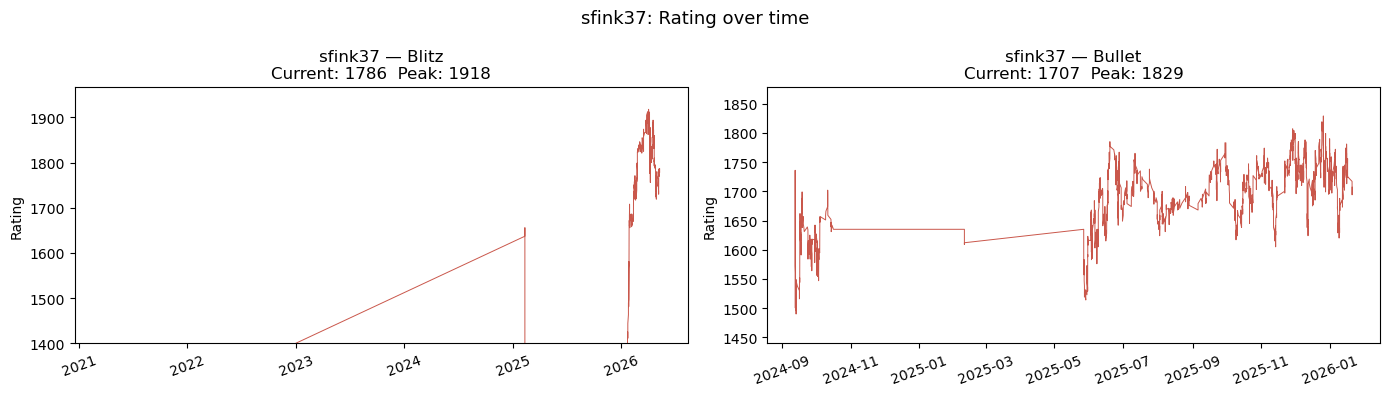

In [27]:
tc_list = sorted(TIME_CLASSES)
fig, axes = plt.subplots(1, len(tc_list), figsize=(7 * len(tc_list), 4))
if len(tc_list) == 1:
    axes = [axes]

for ax, tc in zip(axes, tc_list):
    tc_games = [g for g in games if g['time_class'] == tc and g['my_rating'] > 0]
    if not tc_games:
        ax.set_title(f'{tc} — no data')
        continue
    dates   = [datetime.datetime.fromtimestamp(g['end_time']) for g in tc_games]
    ratings = [g['my_rating'] for g in tc_games]
    ax.plot(dates, ratings, linewidth=0.7, alpha=0.85, color=COL_PRIMARY)
    ax.set_title(f'{DISPLAY_NAME} — {tc.capitalize()}\nCurrent: {ratings[-1]}  Peak: {max(ratings)}')
    ax.set_ylabel('Rating')
    ax.set_ylim(max(RATING_FLOOR, min(ratings) - 50), max(ratings) + 50)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle(f'{DISPLAY_NAME}: Rating over time', fontsize=13)
plt.tight_layout()
plt.show()

## Step 4 — Game phase analysis

In [28]:
def count_halfmoves(pgn_str):
    try:
        game = chess.pgn.read_game(io.StringIO(pgn_str))
        return len(list(game.mainline_moves()))
    except Exception:
        return 0

def assign_phase(hm):
    if hm <= OPENING_END: return 'Opening'
    if hm <= MG_END:      return 'Middlegame'
    return 'Endgame'

for g in games:
    g['halfmoves'] = count_halfmoves(g['pgn'])
    g['phase']     = assign_phase(g['halfmoves'])

losses        = [g for g in games if g['outcome'] == 'loss']
phases        = ['Opening', 'Middlegame', 'Endgame']
phase_counts  = Counter(g['phase'] for g in losses)
total_losses  = len(losses)

print(f'{DISPLAY_NAME}: {total_losses} losses by phase')
for ph in phases:
    n   = phase_counts[ph]
    pct = 100 * n / total_losses if total_losses else 0
    bar = '#' * int(pct / 2)
    print(f'  {ph:12s}: {n:4d}  ({pct:.1f}%)  {bar}')

sfink37: 2210 losses by phase
  Opening     :   24  (1.1%)  
  Middlegame  :  515  (23.3%)  ###########
  Endgame     : 1671  (75.6%)  #####################################


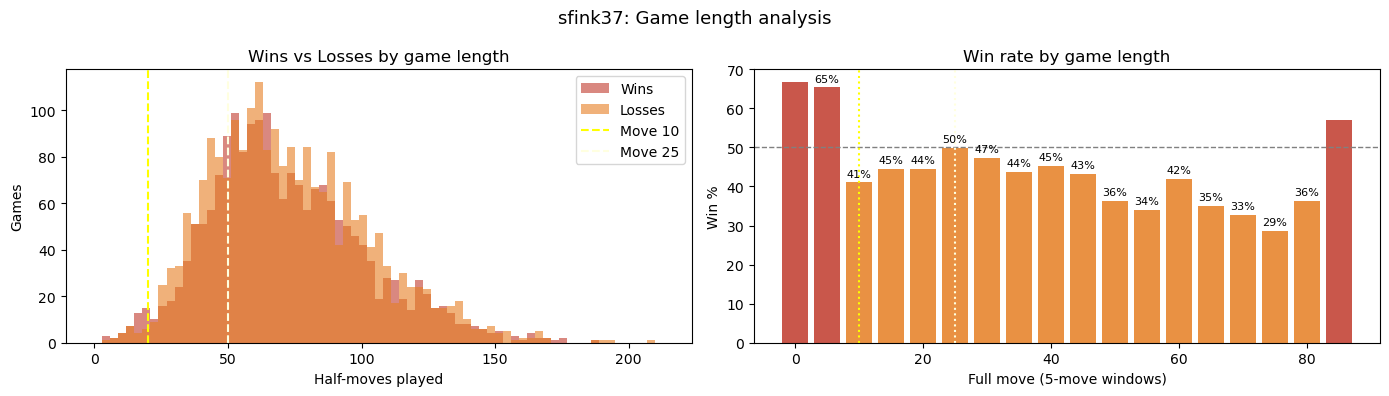

In [29]:
loss_hm = [g['halfmoves'] for g in losses]
win_hm  = [g['halfmoves'] for g in games if g['outcome'] == 'win']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

bins = range(0, max(loss_hm + win_hm) + 5, 3)
axes[0].hist(win_hm,  bins=bins, color=COL_PRIMARY,   alpha=0.6, label='Wins',   edgecolor='none')
axes[0].hist(loss_hm, bins=bins, color=COL_SECONDARY, alpha=0.6, label='Losses', edgecolor='none')
axes[0].axvline(OPENING_END, color='yellow',      linestyle='--', linewidth=1.5, label=f'Move {OPENING_END//2}')
axes[0].axvline(MG_END,      color='lightyellow', linestyle='--', linewidth=1.5, label=f'Move {MG_END//2}')
axes[0].set_xlabel('Half-moves played')
axes[0].set_ylabel('Games')
axes[0].set_title('Wins vs Losses by game length')
axes[0].legend()

# Win rate by 5-move bucket
bucket_size  = 10
bucket_stats = defaultdict(Counter)
for g in games:
    bucket_stats[(g['halfmoves'] // bucket_size) * bucket_size][g['outcome']] += 1

xs, wrs, ns = [], [], []
for b in sorted(bucket_stats):
    c = bucket_stats[b]
    t = sum(c.values())
    if t < 5: continue
    xs.append(b // 2)
    wrs.append(100 * c['win'] / t)
    ns.append(t)

bar_colors = [COL_PRIMARY if wr >= 50 else COL_SECONDARY for wr in wrs]
axes[1].bar(xs, wrs, width=4, color=bar_colors, edgecolor='none', alpha=0.85)
axes[1].axhline(50, color='gray', linestyle='--', linewidth=1)
axes[1].axvline(OPENING_END // 2, color='yellow',      linestyle=':', linewidth=1.5)
axes[1].axvline(MG_END // 2,      color='lightyellow', linestyle=':', linewidth=1.5)
axes[1].set_xlabel('Full move (5-move windows)')
axes[1].set_ylabel('Win %')
axes[1].set_title('Win rate by game length')
for bar, wr, n in zip(axes[1].patches, wrs, ns):
    if n >= 15:
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                     f'{wr:.0f}%', ha='center', fontsize=8)

plt.suptitle(f'{DISPLAY_NAME}: Game length analysis', fontsize=13)
plt.tight_layout()
plt.show()

## Step 5 — How losses end (by phase)

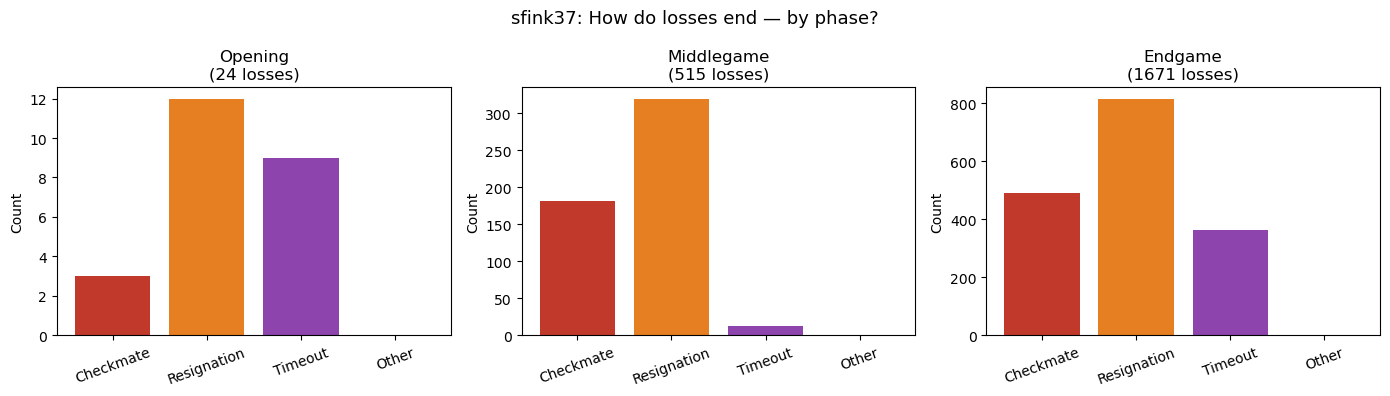

Timeout losses: 386 / 2210 (17.5%)


In [30]:
def classify_end(reason):
    if reason == 'checkmated':             return 'Checkmate'
    if reason in ('resigned', 'lose'):     return 'Resignation'
    if reason in ('timeout','abandoned'):  return 'Timeout'
    return 'Other'

end_types  = ['Checkmate', 'Resignation', 'Timeout', 'Other']
colors_end = ['#c0392b', '#e67e22', '#8e44ad', '#888']
phase_end  = {ph: Counter() for ph in phases}
for g in losses:
    phase_end[g['phase']][classify_end(g['end_reason'])] += 1

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, ph in zip(axes, phases):
    c = phase_end[ph]
    ax.bar(end_types, [c[et] for et in end_types], color=colors_end, edgecolor='none')
    ax.set_title(f'{ph}\n({sum(c.values())} losses)')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=20)
plt.suptitle(f'{DISPLAY_NAME}: How do losses end — by phase?', fontsize=13)
plt.tight_layout()
plt.show()

# Timeout rate across all losses
timeout_losses = sum(1 for g in losses if classify_end(g['end_reason']) == 'Timeout')
print(f'Timeout losses: {timeout_losses} / {total_losses} ({100*timeout_losses/total_losses:.1f}%)')

## Step 6 — Opening performance (by volume, min games from config)

In [31]:
def opening_label(url, words=4):
    if '/openings/' not in url: return 'Unknown'
    return ' '.join(url.split('/openings/')[-1].split('-')[:words])

opening_stats = defaultdict(Counter)
for g in games:
    lbl = opening_label(g['eco_url'])
    opening_stats[lbl][g['outcome']] += 1

rows = []
for lbl, c in opening_stats.items():
    t = sum(c.values())
    if t < MIN_OPN_GAMES: continue
    wr = 100 * c['win'] / t
    rows.append((lbl, c['win'], c['loss'], c['draw'], t, round(wr, 1)))

rows.sort(key=lambda x: -x[4])  # sort by games played

print(f'{DISPLAY_NAME}: Top openings by games played (min {MIN_OPN_GAMES} games)')
print(f'{"Opening":<45} {"W":>4} {"L":>4} {"D":>3} {"Total":>6} {"Win%":>6}')
print('-' * 72)
for r in rows[:20]:
    print(f'{r[0][:45]:<45} {r[1]:>4} {r[2]:>4} {r[3]:>3} {r[4]:>6} {r[5]:>6.1f}%')

sfink37: Top openings by games played (min 10 games)
Opening                                          W    L   D  Total   Win%
------------------------------------------------------------------------
Giuoco Piano Game Giuoco                       122  103  19    244   50.0%
Sicilian Defense Bowdler Attack                101   86  14    201   50.2%
Sicilian Defense Old Sicilian                   79   76   8    163   48.5%
Ruy Lopez Opening Classical                     78   61   3    142   54.9%
Giuoco Piano Game Main                          64   58  10    132   48.5%
Caro Kann Defense Advance                       48   65   9    122   39.3%
Closed Sicilian Defense Traditional             62   52   5    119   52.1%
Ruy Lopez Opening                               54   48   7    109   49.5%
Giuoco Piano Game 4.O                           54   39   7    100   54.0%
French Defense Exchange Variation               42   52   5     99   42.4%
Scandinavian Defense Mieses Kotrc               37

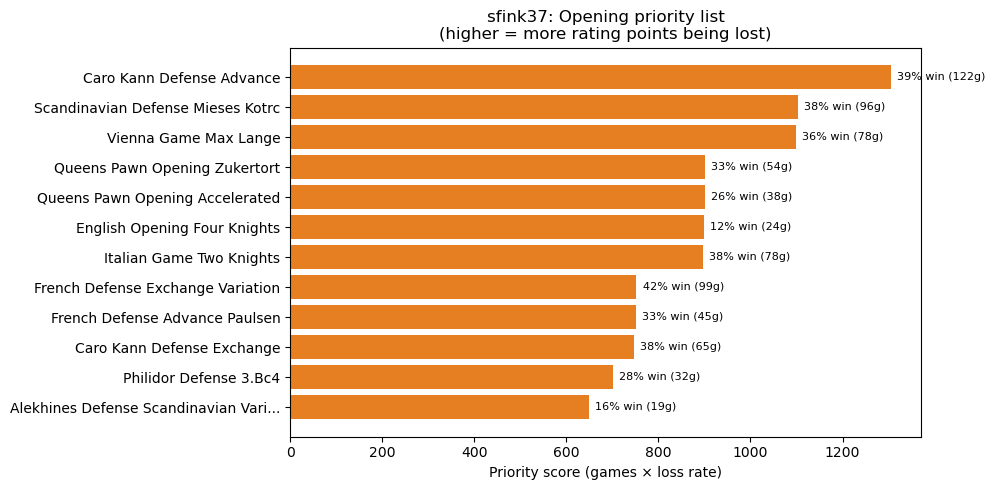

In [32]:
# Priority openings: volume × (50 - win rate) — most costly underperformers
priority = [(r[0], r[4], r[5], r[4] * (50 - r[5])) for r in rows if r[4] * (50 - r[5]) > 0]
priority.sort(key=lambda x: -x[3])

top = priority[:12]
labels = [r[0][:35] + '...' if len(r[0]) > 35 else r[0] for r in top]
scores = [r[3] for r in top]
wrs    = [r[2] for r in top]
bar_cols = [COL_SECONDARY if wr < 40 else '#e67e22' for wr in wrs]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(labels[::-1], scores[::-1], color=bar_cols[::-1], edgecolor='none')
ax.set_xlabel('Priority score (games × loss rate)')
ax.set_title(f'{DISPLAY_NAME}: Opening priority list\n(higher = more rating points being lost)')
for bar, r in zip(bars, top[::-1]):
    ax.text(bar.get_width() + max(scores)*0.01, bar.get_y() + bar.get_height()/2,
            f'{r[2]:.0f}% win ({r[1]}g)', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## Step 7 — Summary

In [33]:
opening_pct    = 100 * phase_counts.get('Opening', 0)    / total_losses
middlegame_pct = 100 * phase_counts.get('Middlegame', 0) / total_losses
endgame_pct    = 100 * phase_counts.get('Endgame', 0)    / total_losses
dominant_phase = max(phase_counts, key=phase_counts.get) if phase_counts else 'N/A'

print(f'{DISPLAY_NAME.upper()} — SUMMARY')
print('=' * 50)
print(f'Games:        {total}  |  Win rate: {100*len(wins)/total:.1f}%')
print(f'As white:     {100*w_wins/w_total:.1f}%  |  As black: {100*b_wins/b_total:.1f}%')
print()
print('Loss phase breakdown:')
print(f'  Opening:    {phase_counts.get("Opening", 0):4d}  ({opening_pct:.1f}%)')
print(f'  Middlegame: {phase_counts.get("Middlegame", 0):4d}  ({middlegame_pct:.1f}%)')
print(f'  Endgame:    {phase_counts.get("Endgame", 0):4d}  ({endgame_pct:.1f}%)')
print(f'\nDominant loss phase: {dominant_phase}')
print(f'Timeout losses: {timeout_losses} ({100*timeout_losses/total_losses:.1f}%)')
print()
if priority:
    print(f'Top priority opening: {priority[0][0]} ({priority[0][2]:.0f}% win, {priority[0][1]} games)')
print()
if opening_pct > 35:
    print('>> Opening study is high priority.')
if middlegame_pct > 40:
    print('>> Middlegame is the main problem — tactical/positional training needed.')
if endgame_pct > 30:
    print('>> Endgame technique study warranted.')
if timeout_losses / total_losses > 0.15:
    print('>> Time management is a significant issue.')

SFINK37 — SUMMARY
Games:        4412  |  Win rate: 44.1%
As white:     43.9%  |  As black: 44.2%

Loss phase breakdown:
  Opening:      24  (1.1%)
  Middlegame:  515  (23.3%)
  Endgame:    1671  (75.6%)

Dominant loss phase: Endgame
Timeout losses: 386 (17.5%)

Top priority opening: Caro Kann Defense Advance (39% win, 122 games)

>> Endgame technique study warranted.
>> Time management is a significant issue.
